<a href="https://colab.research.google.com/github/afifahsalsabila173-ca/ultimate-student-productivity/blob/main/uts_data_mining_salsabila_afifah_2304020155.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. persiapan data**

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [2]:
from google.colab import files
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [3]:
# Upload file data_training.csv dan data_testing.csv
uploaded = files.upload()

Saving data_training.csv to data_training (1).csv
Saving data_testing.csv to data_testing (1).csv


Dataset training digunakan untuk membangun model klasifikasi, sedangkan dataset testing digunakan untuk menghasilkan prediksi akhir.

In [4]:
# Membaca dataset training dan testing
data_training = pd.read_csv("data_training.csv")
data_testing = pd.read_csv("data_testing.csv")

In [5]:
# Menampilkan ukuran dataset
print("Ukuran data training:", data_training.shape)
print("Ukuran data testing:", data_testing.shape)

Ukuran data training: (857, 13)
Ukuran data testing: (286, 12)


Output shape menunjukkan jumlah baris dan kolom pada masing-masing dataset. Data training memiliki kolom target quality, sedangkan data testing tidak memiliki kolom quality karena nilai tersebut harus diprediksi oleh model.

In [6]:
# Menampilkan 5 data pertama pada data training
data_training.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


**2. Pembersihan data**

In [7]:
# Mengecek missing values pada data training
print("Missing values pada data training:")
print(data_training.isnull().sum())


Missing values pada data training:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [8]:
# Mengecek missing values pada data testing
print("\nMissing values pada data testing:")
print(data_testing.isnull().sum())


Missing values pada data testing:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


dilakukan pengecekan missing values pada data training dan data testing. Jika terdapat nilai kosong, nilai tersebut akan ditangani menggunakan metode imputasi median pada pipeline model.

In [38]:
# Memisahkan fitur dan target

# Kolom quality adalah target
# Kolom Id/id hanya sebagai identitas, sehingga tidak digunakan sebagai fitur model
feature_cols = [col for col in data_training.columns if col not in ["quality", "Id", "id"]]

X = data_training[feature_cols]
y = data_training["quality"]

X_test = data_testing[feature_cols]

print("Fitur yang digunakan:")
print(feature_cols)

print("\nJumlah fitur:", len(feature_cols))
print("\nDistribusi nilai quality:")
print(y.value_counts().sort_index())

Fitur yang digunakan:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Jumlah fitur: 11

Distribusi nilai quality:
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64


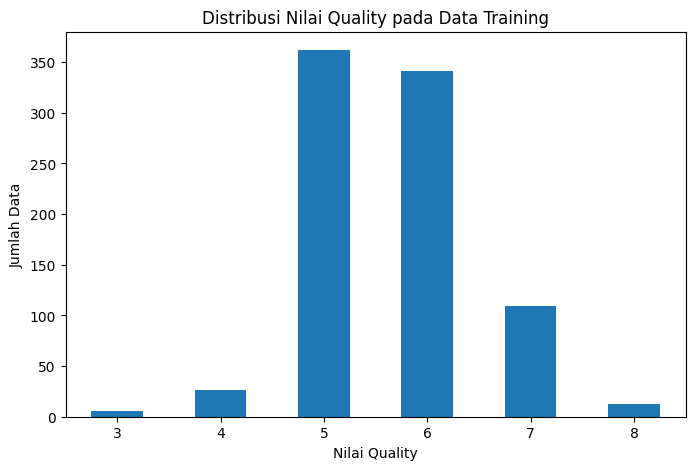

In [39]:
# Visualisasi distribusi nilai quality

plt.figure(figsize=(8, 5))
y.value_counts().sort_index().plot(kind="bar")

plt.title("Distribusi Nilai Quality pada Data Training")
plt.xlabel("Nilai Quality")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)
plt.show()

menunjukkan jumlah data pada setiap kategori nilai quality. Dari grafik ini dapat dilihat apakah data memiliki distribusi yang seimbang atau tidak. Jika jumlah data pada beberapa kategori jauh lebih sedikit, maka dataset dapat dikatakan memiliki ketidakseimbangan kelas.

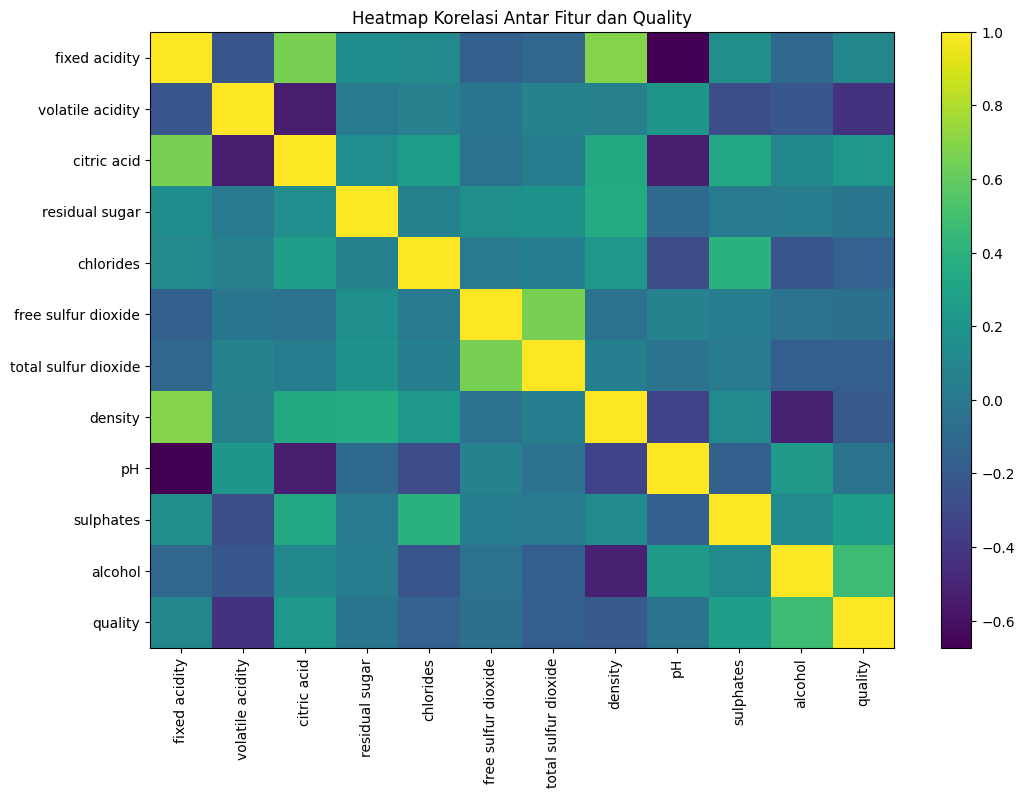

In [31]:
# Visualisasi korelasi antar fitur

import matplotlib.pyplot as plt

correlation_matrix = data_training[feature_cols + ["quality"]].corr()

plt.figure(figsize=(12, 8))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Heatmap Korelasi Antar Fitur dan Quality")
plt.show()

digunakan untuk melihat hubungan antar fitur kimiawi dengan variabel quality. Nilai korelasi yang semakin mendekati 1 atau -1 menunjukkan hubungan yang semakin kuat.

<Figure size 800x500 with 0 Axes>

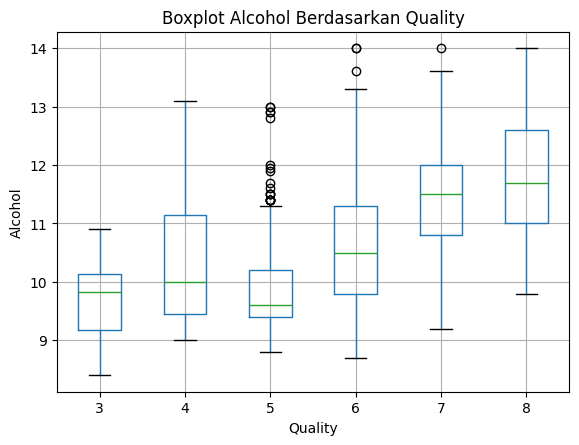

In [32]:
# Boxplot alcohol berdasarkan quality

plt.figure(figsize=(8, 5))
data_training.boxplot(column="alcohol", by="quality")

plt.title("Boxplot Alcohol Berdasarkan Quality")
plt.suptitle("")
plt.xlabel("Quality")
plt.ylabel("Alcohol")
plt.show()

menunjukkan sebaran kadar alcohol pada setiap nilai quality. Grafik ini membantu melihat apakah kadar alkohol memiliki pola tertentu terhadap kualitas anggur.

In [9]:
# Memisahkan fitur dan target
# Kolom quality adalah target yang akan diprediksi
# Kolom Id/id tidak digunakan sebagai fitur karena hanya sebagai identitas data

feature_cols = [col for col in data_training.columns if col not in ["quality", "Id", "id"]]

X = data_training[feature_cols]
y = data_training["quality"]

X_test = data_testing[feature_cols]

In [10]:
# Menampilkan fitur yang digunakan
print("\nFitur yang digunakan untuk model:")
print(feature_cols)


Fitur yang digunakan untuk model:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [11]:
# Menampilkan distribusi nilai quality
print("\nDistribusi nilai quality:")
print(y.value_counts().sort_index())


Distribusi nilai quality:
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64


menunjukkan jumlah data pada setiap kategori nilai quality. Dari grafik ini dapat dilihat apakah data memiliki distribusi yang seimbang atau tidak. Jika jumlah data pada beberapa kategori jauh lebih sedikit, maka dataset dapat dikatakan memiliki ketidakseimbangan kelas.

**3. Pembuatan model**

digunakan algoritma Random Forest Classifier. Model ini dipilih karena cocok untuk data tabular, mampu menangani hubungan antar fitur yang kompleks, dan tidak terlalu sensitif terhadap skala data dibandingkan beberapa algoritma lain.

In [12]:
# Membuat model menggunakan Pipeline
# SimpleImputer digunakan untuk menangani missing values
# RandomForestClassifier digunakan sebagai model klasifikasi

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=150,
        random_state=42,
        class_weight="balanced_subsample",
        max_features="sqrt",
        n_jobs=1
    ))
])

In [40]:
# Membagi data menjadi data latih dan data validasi

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data latih:", X_train.shape)
print("Jumlah data validasi:", X_val.shape)

Jumlah data latih: (685, 11)
Jumlah data validasi: (172, 11)


Data training dibagi menjadi dua bagian, yaitu data latih dan data validasi. Data latih digunakan untuk melatih model, sedangkan data validasi digunakan untuk mengevaluasi kemampuan model dalam memprediksi data yang belum pernah dilihat sebelumnya.

In [14]:
# Melatih model menggunakan data latih
model.fit(X_train, y_train)


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        n_estimators=150, n_jobs=1,
                                        random_state=42))])

In [15]:
# Melakukan prediksi pada data validasi
y_pred_val = model.predict(X_val)

In [17]:
# Menghitung akurasi model
accuracy = accuracy_score(y_val, y_pred_val)

print("Akurasi model pada data validasi:", accuracy)


Akurasi model pada data validasi: 0.5930232558139535


Nilai akurasi menunjukkan seberapa besar persentase prediksi model yang benar pada data validasi. Semakin tinggi nilai akurasi, maka semakin baik performa model. Namun, karena target quality memiliki beberapa kelas, evaluasi tidak hanya dilihat dari akurasi saja, tetapi juga dari confusion matrix dan classification report.

In [18]:
# Menampilkan confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_val))



Confusion Matrix:
[[ 0  0  0  1  0  0]
 [ 0  0  5  0  0  0]
 [ 0  0 56 17  0  0]
 [ 0  0 26 39  3  0]
 [ 0  0  0 16  6  0]
 [ 0  0  0  0  2  1]]


menunjukkan perbandingan antara nilai aktual dan hasil prediksi. Nilai yang berada pada diagonal utama menunjukkan prediksi yang benar, sedangkan nilai di luar diagonal menunjukkan prediksi yang salah. Jika nilai pada diagonal lebih dominan, maka model dapat dikatakan cukup baik.

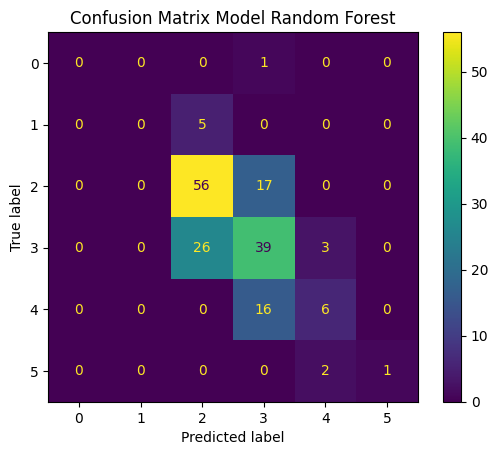

In [29]:
# Visualisasi confusion matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_val, y_pred_val)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix Model Random Forest")
plt.show()

digunakan untuk melihat hasil prediksi model terhadap data validasi. Nilai diagonal menunjukkan prediksi yang benar, sedangkan nilai di luar diagonal menunjukkan prediksi yang salah. Semakin banyak nilai pada diagonal, maka semakin baik performa model.

In [19]:
# Menampilkan classification report
print("\nClassification Report:")
print(classification_report(y_val, y_pred_val, zero_division=0))


Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.64      0.77      0.70        73
           6       0.53      0.57      0.55        68
           7       0.55      0.27      0.36        22
           8       1.00      0.33      0.50         3

    accuracy                           0.59       172
   macro avg       0.45      0.32      0.35       172
weighted avg       0.57      0.59      0.57       172



menampilkan precision, recall, dan f1-score untuk setiap kelas quality. Precision menunjukkan ketepatan prediksi model pada suatu kelas, recall menunjukkan kemampuan model menemukan data pada kelas tersebut, sedangkan f1-score merupakan gabungan dari precision dan recall.

In [20]:
# Evaluasi tambahan menggunakan cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=1
)

print("Skor Cross Validation:", cv_scores)
print("Rata-rata Akurasi Cross Validation:", cv_scores.mean())
print("Standar Deviasi Cross Validation:", cv_scores.std())

Skor Cross Validation: [0.5872093  0.6744186  0.61988304 0.66081871 0.68421053]
Rata-rata Akurasi Cross Validation: 0.6453080375356997
Standar Deviasi Cross Validation: 0.036395887964228185


digunakan sebagai evaluasi tambahan agar performa model lebih stabil. Dengan metode ini, data dibagi menjadi 5 bagian dan model diuji secara bergantian. Rata-rata akurasi cross validation menunjukkan gambaran performa model secara lebih menyeluruh.

In [41]:
# Melatih ulang model pada data latih agar bisa melihat feature importance

model.fit(X_train, y_train)

rf_model = model.named_steps["classifier"]

feature_importance = pd.DataFrame({
    "Fitur": feature_cols,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Fitur,Importance
1,volatile acidity,0.145506
9,sulphates,0.126659
10,alcohol,0.115340
2,citric acid,0.096023
6,total sulfur dioxide,0.093036
4,chlorides,0.083181
7,density,0.079436
8,pH,0.070335
5,free sulfur dioxide,0.070206
0,fixed acidity,0.065305


menunjukkan fitur kimiawi yang paling berpengaruh terhadap prediksi model. Fitur dengan nilai importance paling tinggi berarti memiliki kontribusi lebih besar dalam menentukan hasil prediksi quality.

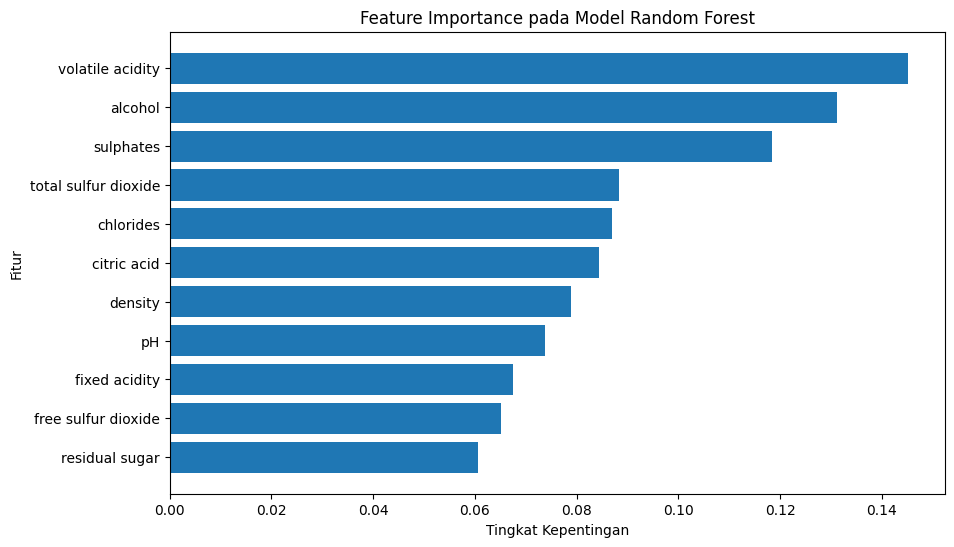

In [30]:
# Visualisasi feature importance

import matplotlib.pyplot as plt
import pandas as pd

# Mengambil nilai feature importance dari model Random Forest
rf_model = model.named_steps["classifier"]

feature_importance = pd.DataFrame({
    "Fitur": feature_cols,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Fitur"], feature_importance["Importance"])
plt.xlabel("Tingkat Kepentingan")
plt.ylabel("Fitur")
plt.title("Feature Importance pada Model Random Forest")
plt.gca().invert_yaxis()
plt.show()

menunjukkan fitur kimiawi apa saja yang paling berpengaruh dalam menentukan prediksi kualitas anggur. Semakin tinggi nilai importance, semakin besar pengaruh fitur tersebut terhadap model.

**4. Prediksi data uji**

model dilatih kembali menggunakan seluruh data training. Hal ini dilakukan agar model dapat mempelajari seluruh pola yang ada pada dataset training sebelum digunakan untuk memprediksi data testing.

In [21]:
# Melatih ulang model menggunakan seluruh data training
# Tujuannya agar model mempelajari seluruh pola pada data training
model.fit(X, y)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        n_estimators=150, n_jobs=1,
                                        random_state=42))])

In [22]:
# Melakukan prediksi pada data testing
hasil_quality = model.predict(X_test).astype(int)


In [43]:
# Melihat distribusi hasil prediksi

print("Distribusi hasil prediksi quality:")
print(hasil_prediksi["quality"].value_counts().sort_index())

Distribusi hasil prediksi quality:
quality
5    135
6    124
7     27
Name: count, dtype: int64


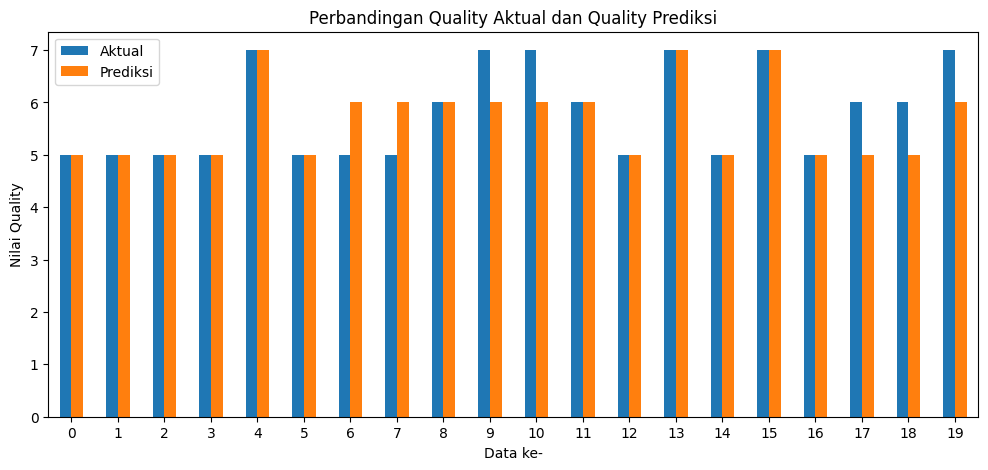

In [33]:
# Perbandingan data aktual dan prediksi pada data validasi

comparison = pd.DataFrame({
    "Aktual": y_val.values,
    "Prediksi": y_pred_val
})

comparison.head(20).plot(kind="bar", figsize=(12, 5))

plt.title("Perbandingan Quality Aktual dan Quality Prediksi")
plt.xlabel("Data ke-")
plt.ylabel("Nilai Quality")
plt.xticks(rotation=0)
plt.show()

membandingkan nilai quality asli dengan hasil prediksi model pada data validasi. Jika tinggi batang aktual dan prediksi banyak yang sama atau berdekatan, maka model dapat dikatakan cukup baik.

In [23]:
# Membuat dataframe hasil prediksi
# Sesuai instruksi, file hanya memuat 2 variabel yaitu id dan quality

hasil_prediksi = pd.DataFrame({
    "id": data_testing["Id"].astype(int),
    "quality": hasil_quality
})

In [24]:
# Menampilkan 5 hasil prediksi pertama
hasil_prediksi.head()

,id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,6


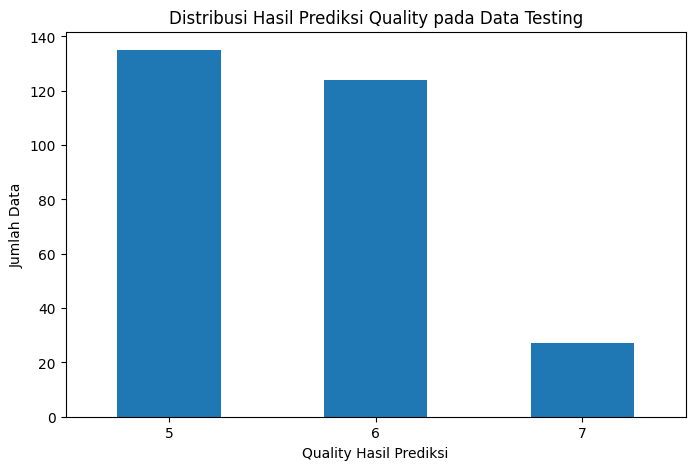

In [34]:
# Distribusi hasil prediksi quality pada data testing

plt.figure(figsize=(8, 5))
hasil_prediksi["quality"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribusi Hasil Prediksi Quality pada Data Testing")
plt.xlabel("Quality Hasil Prediksi")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)
plt.show()

menunjukkan persebaran hasil prediksi kualitas anggur pada data testing. Dari grafik ini dapat dilihat nilai kualitas mana yang paling banyak diprediksi oleh model.

In [25]:
# Menyimpan hasil prediksi ke dalam file CSV
hasil_prediksi.to_csv("hasilprediksi_final.csv", index=False)

print("File hasil prediksi berhasil dibuat.")
print("Nama file: hasilprediksi_final.csv")
print("Jumlah baris dan kolom:", hasil_prediksi.shape)
print("Kolom pada file:", list(hasil_prediksi.columns))

# Menampilkan beberapa data hasil prediksi
hasil_prediksi.head()

File hasil prediksi berhasil dibuat.
Nama file: hasilprediksi_final.csv
Jumlah baris dan kolom: (286, 2)
Kolom pada file: ['id', 'quality']


,id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,6


In [45]:
# Menyimpan hasil prediksi ke CSV
# File hanya berisi 2 kolom: id dan quality

hasil_prediksi.to_csv("hasilprediksi_final.csv", index=False)

print("File hasil prediksi berhasil dibuat.")
print("Nama file: hasilprediksi_final.csv")
print("Jumlah baris dan kolom:", hasil_prediksi.shape)
print("Kolom pada file:", list(hasil_prediksi.columns))

hasil_prediksi.head()

File hasil prediksi berhasil dibuat.
Nama file: hasilprediksi_final.csv
Jumlah baris dan kolom: (286, 2)
Kolom pada file: ['id', 'quality']


,id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,6


In [46]:
# Download file hasil prediksi
files.download("hasilprediksi_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
joblib.dump(model, "model_uts_datamining_SalsabilaAfifah_2304020155.pkl")

print("Model berhasil disimpan dengan nama model_uts_datamining_SalsabilaAfifah_2304020155.pkl")

Model berhasil disimpan dengan nama model_uts_datamining_SalsabilaAfifah_2304020155.pkl


In [50]:
# Download model
files.download("model_uts_datamining_SalsabilaAfifah_2304020155.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>